# Testing samples for ARCH effects
The main problem with my first run was a lack of ARCH-effects in my sample. Therefore I collected samples from different timeframes and tested the return series on ARCH effects.

In [1]:
# Import data handling
import pandas as pd
import numpy as np

# Import visualization
import matplotlib.pyplot as plt

# Import statistical tools
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [2]:
# Loading data
file = "../code/data/find_arch_effects/timeframes/2023_feb-april.csv"
df = pd.read_csv(file, sep=",", usecols=['timestamp', 'price'])

# Calculate return series and squared_return series in basis points
df = df.dropna(subset=["price"])
df["return"] = 10000 * np.log(df["price"] / df["price"].shift(1))
df = df.dropna(subset=["return"])
df["timestamp"] = pd.to_datetime(df["timestamp"], yearfirst= True, utc=True)
df.set_index("timestamp", inplace=True)

# Descriptive statistics
print(df.info())
print(df.head(10))

<class 'pandas.DataFrame'>
DatetimeIndex: 25632 entries, 2023-02-01 00:05:00+00:00 to 2023-05-01 00:00:00+00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   25632 non-null  float64
 1   return  25632 non-null  float64
dtypes: float64(2)
memory usage: 600.8 KB
None
                             price    return
timestamp                                   
2023-02-01 00:05:00+00:00  0.99996 -0.000392
2023-02-01 00:10:00+00:00  0.99996 -0.000336
2023-02-01 00:15:00+00:00  0.99996  0.000000
2023-02-01 00:20:00+00:00  0.99996 -0.000525
2023-02-01 00:25:00+00:00  0.99996  0.000814
2023-02-01 00:30:00+00:00  0.99996  0.000000
2023-02-01 00:35:00+00:00  0.99996 -0.002955
2023-02-01 00:40:00+00:00  0.99996  0.000016
2023-02-01 00:45:00+00:00  0.99996 -0.000034
2023-02-01 00:50:00+00:00  0.99996 -0.000145


## 2023 March collapse of SVB & USDC de-peg

When SVB collapsed in March of 2023, USDC de-pegged, while USDT held its peg. Given that the peg collapsed I expect volatility clustering especially around and after the collapse, as the stabilization mechanisms should have failed.

First, I want to look at visual cues. Stacked on top of each other I want to display the price series, return series and rolling (1-day) volatility. For both the returns and volatility series, I use a (symmetrically) logarithmic scale, as during the collapse, prices fell by 0.35, which would result in 4000 bps of return and make the rest of the sample impossible to visualize alongside it.

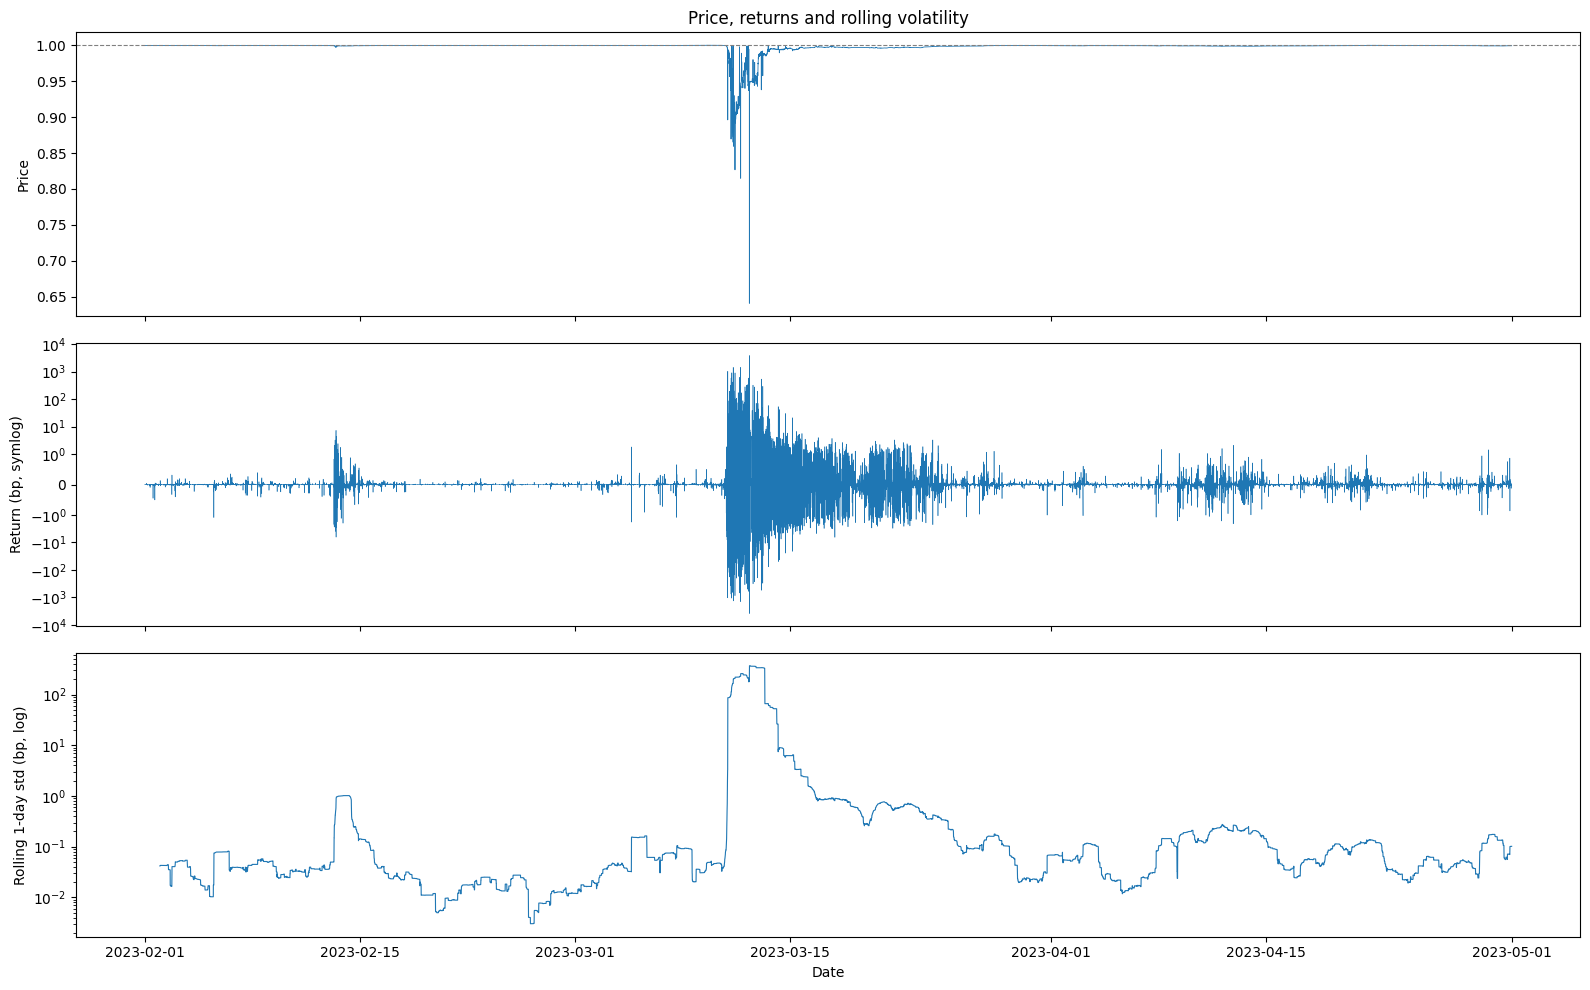

In [3]:
# Visualize data
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)       # stacking on top of each other -> 3 rows, 1 column, sharing x-Axis

# Price, with the peg marked
axes[0].plot(df.index, df["price"], lw=0.6)                 # plot(x_Axis, y_Axis, linewidth)
axes[0].axhline(1.0, color="grey", ls="--", lw=0.8)         # axis horizontal line (set at 1.0 (peg))
axes[0].set_ylabel("Price")                                 # label for y Axis
axes[0].set_title("Price, returns and rolling volatility")  # titel OVERALL

# Returns on a symlog scale
axes[1].plot(df.index, df["return"], lw=0.4)                # x_axis = index = datetime
axes[1].set_yscale("symlog", linthresh=1)                   # symmetric log -> mirrored log type at negative values
axes[1].set_ylabel("Return (bp, symlog)")

# Rolling 1-day volatility (288 five-minute intervals per day)
rolling_vol = df["return"].rolling(288).std()               # .rolling is a moving window (set to 1 day)
axes[2].plot(rolling_vol.index, rolling_vol, lw=0.8)
axes[2].set_yscale("log")                                   # no need for symlog as never negative
axes[2].set_ylabel("Rolling 1-day std (bp, log)")
axes[2].set_xlabel("Date")

fig.tight_layout()
plt.show()  

Below, I have the sample period of my thesis for comparison. Now that I have a data collection system that can query historically, I can fill all the gaps.

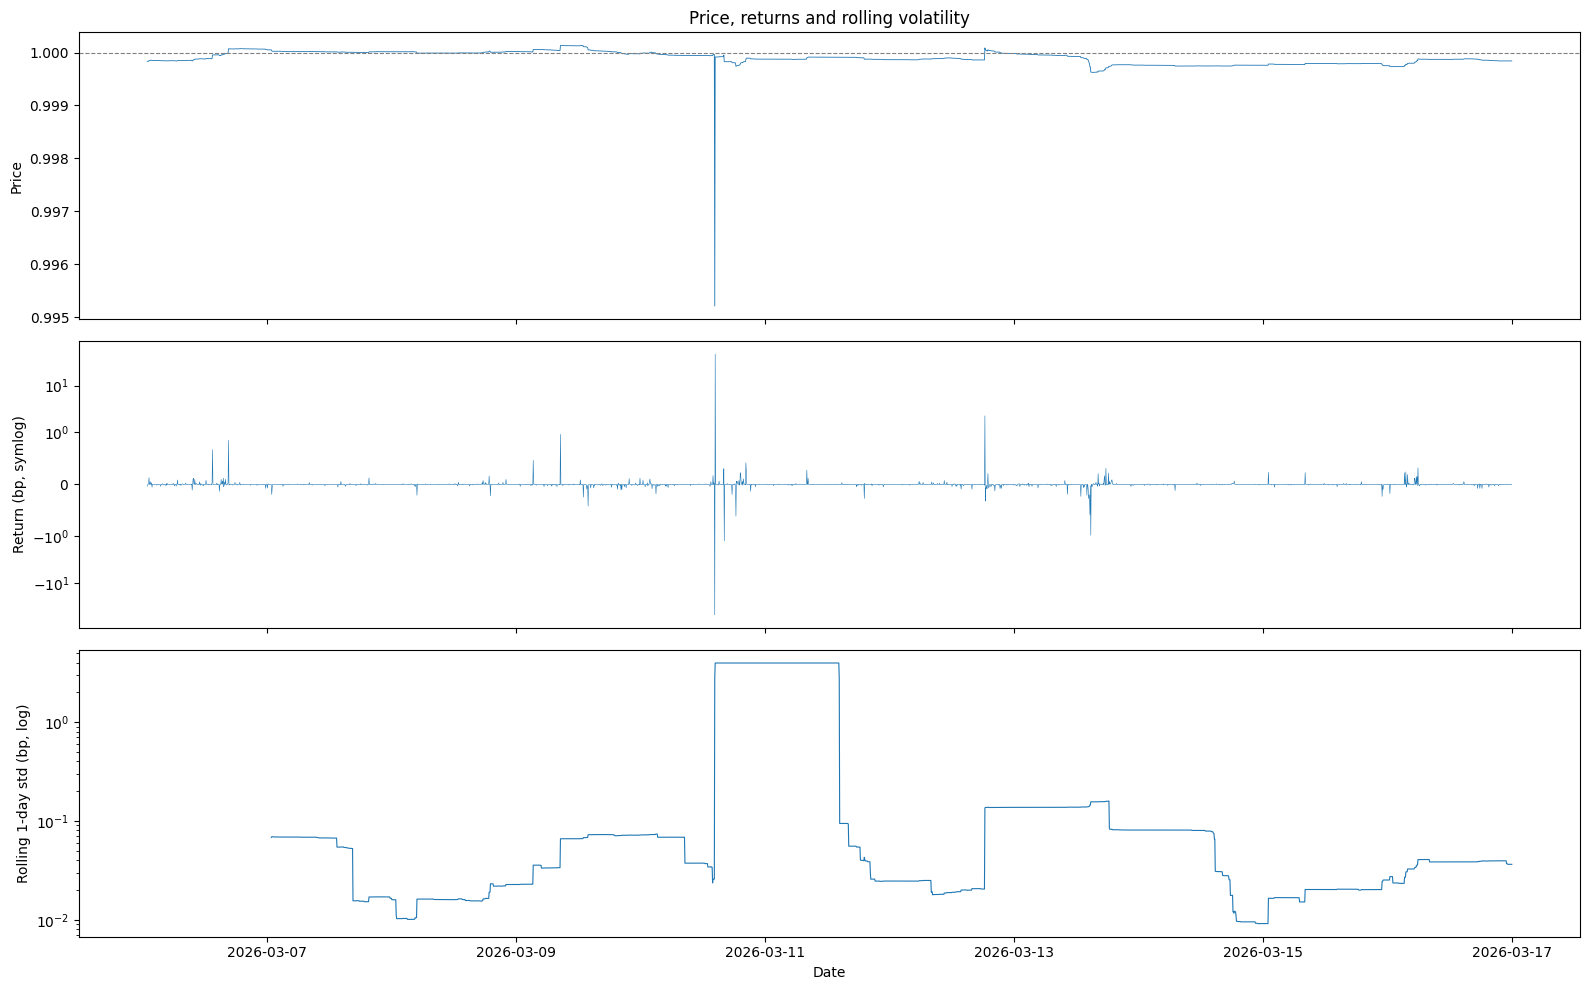

In [4]:
# Import other data set (thesis data set)
file = "../code/data/find_arch_effects/timeframes/2026-thesis_window.csv"
df_thesis = pd.read_csv(file, sep=",", usecols=['timestamp', 'price'])

df_thesis = df_thesis.dropna(subset=["price"])
df_thesis["return"] = 10000 * np.log(df_thesis["price"] / df_thesis["price"].shift(1))
df_thesis = df_thesis.dropna(subset=["return"])
df_thesis["timestamp"] = pd.to_datetime(df_thesis["timestamp"], yearfirst= True, utc=True)
df_thesis.set_index("timestamp", inplace=True)

# Visualize data
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)       # stacking on top of each other -> 3 rows, 1 column, sharing x-Axis

# Price, with the peg marked
axes[0].plot(df_thesis.index, df_thesis["price"], lw=0.6)                 # plot(x_Axis, y_Axis, linewidth)
axes[0].axhline(1.0, color="grey", ls="--", lw=0.8)         # axis horizontal line (set at 1.0 (peg))
axes[0].set_ylabel("Price")                                 # label for y Axis
axes[0].set_title("Price, returns and rolling volatility")  # titel OVERALL

# Returns on a symlog scale
axes[1].plot(df_thesis.index, df_thesis["return"], lw=0.4)                # x_axis = index = datetime
axes[1].set_yscale("symlog", linthresh=1)                   # symmetric log -> mirrored log type at negative values
axes[1].set_ylabel("Return (bp, symlog)")

# Rolling 1-day volatility (288 five-minute intervals per day)
rolling_vol = df_thesis["return"].rolling(288).std()               # .rolling is a moving window (set to 1 day)
axes[2].plot(rolling_vol.index, rolling_vol, lw=0.8)
axes[2].set_yscale("log")                                   # no need for symlog as never negative
axes[2].set_ylabel("Rolling 1-day std (bp, log)")
axes[2].set_xlabel("Date")

fig.tight_layout()
plt.show()  

The comparison is quite striking. Even without the de-peg event pushing volatility high, there is just visibly too little price movement. On a similar timeframe, 2023-04-06 to 2023-04-15, there is much more clustering to be seen. This strengthens the thesis, that there was too little going on during March 2026, when I collected my data.

## ACF and PACF 
While my assumption (that the mean of a stablecoin pair return series is zero, due to the peg) may have held before in a particuliarly calm environment with no significant autocorrolations, it does not hold here. Therefore, the first thing necessary is to estimate an ARMA model and residuals.

Tsay (2010) proposes to use the EACF function to identify ARMA models, but from my knowledge python does not have this function. So I want to use ACF and PACF.

First, I want to check if the data is stationary. For that I use the ADF. If the null is not rejected that implies that the data does not have a constant mean and constant variance and that ARMA is not usable. 

In [5]:
# Check for stationarity
adf_result = adfuller(df["return"])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

ADF Statistic: -21.1005
p-value: 0.0000


Clearly, null can be rejected.

Now, display ACF and PACF to choose `p` and `q` for the ARMA(p,q) model. I also want to check if any result holds for a subsample not including the depeg process.

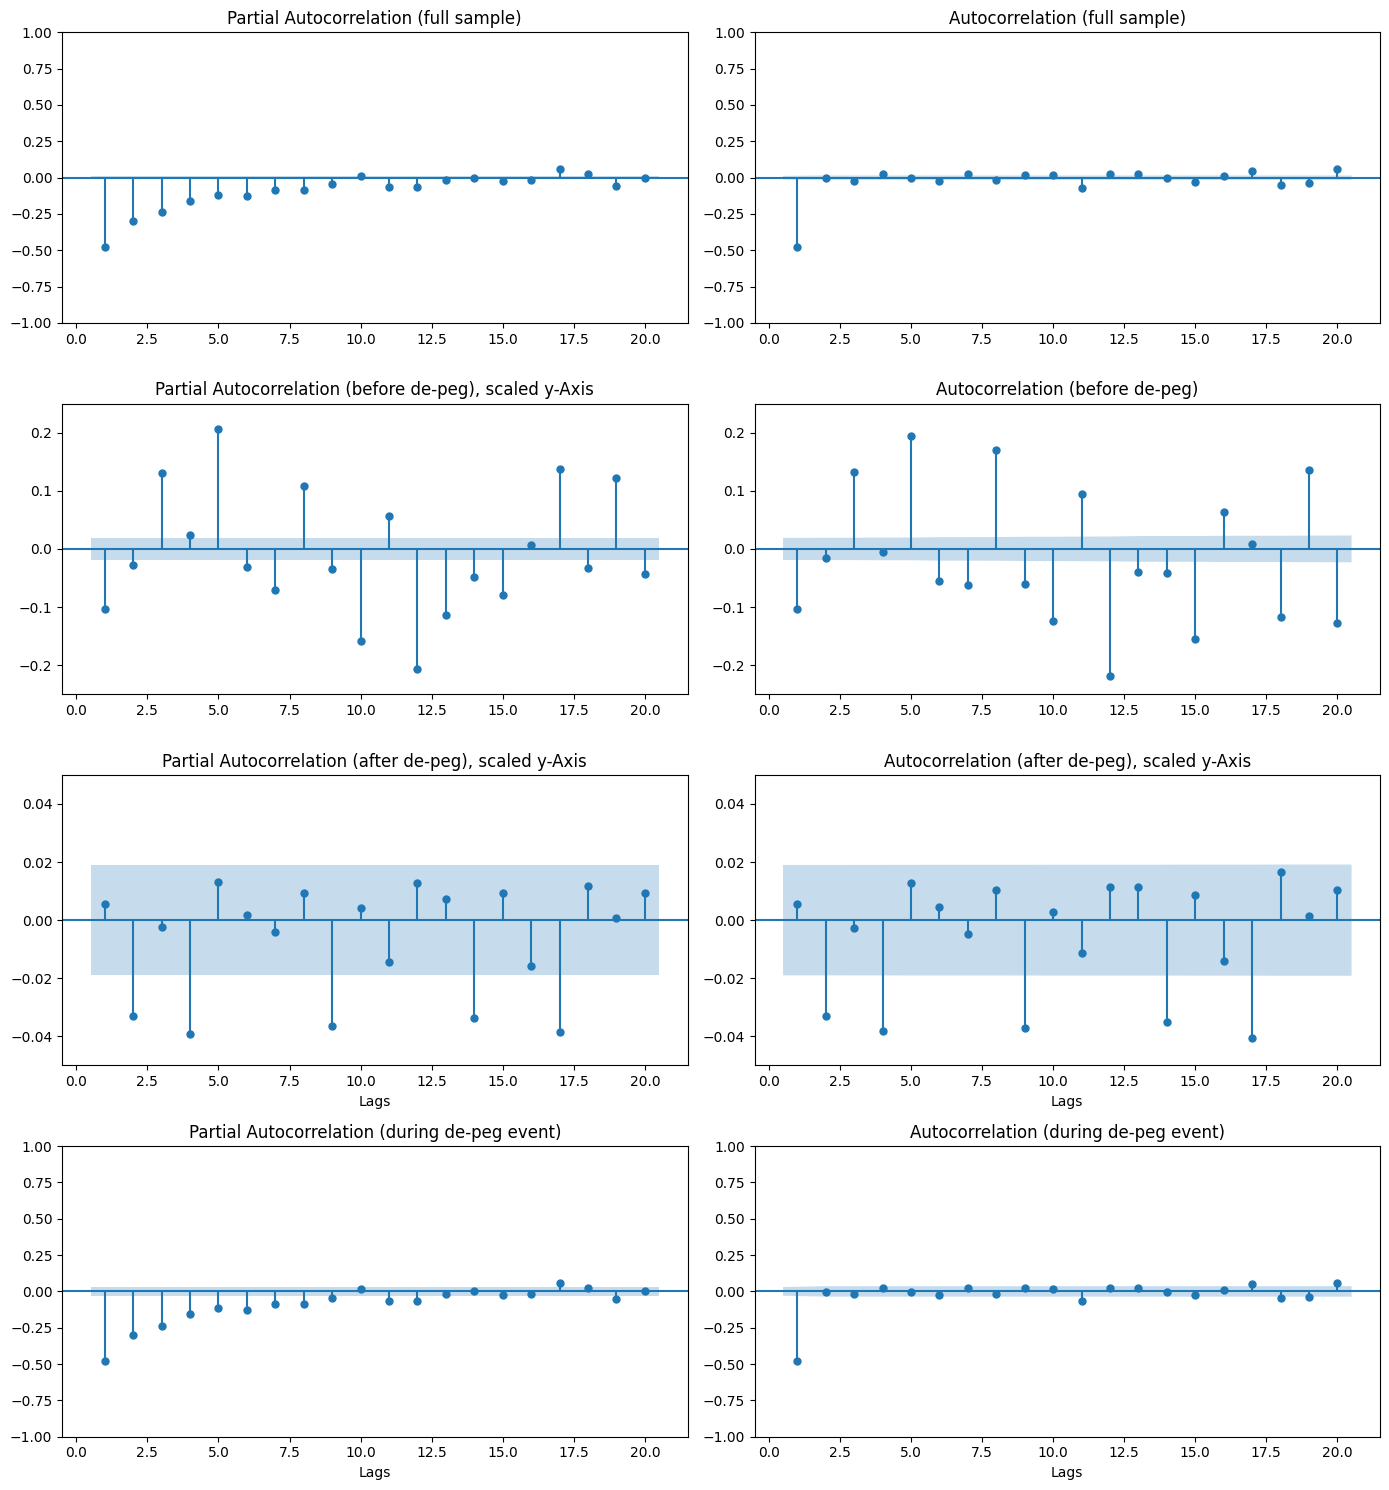

In [ ]:
# Plot
fig, axes = plt.subplots(4,2, figsize=(14,15))

# --- Full sample ----------------------------------------------------------

plot_pacf(df["return"], ax=axes[0][0], lags=20, zero=False, title= "Partial Autocorrelation (full sample)")
plot_acf(df["return"], ax=axes[0][1], lags=20, zero=False, title= "Autocorrelation (full sample)")

# --- Calm period before the depeg ------------------------------------------

calm_mask_before_the_depeg = df.index < "2023-03-10"
calm_before = df.loc[calm_mask_before_the_depeg, "return"]

plot_pacf(calm_before, ax=axes[1][0], lags=20, zero=False, title= "Partial Autocorrelation (before de-peg), scaled y-Axis")
axes[1][0].set_ylim(-0.25, 0.25)

plot_acf(calm_before, ax=axes[1][1], lags=20, zero=False, title= "Autocorrelation (before de-peg)")
axes[1][1].set_ylim(-0.25, 0.25)

# --- Calm period after the depeg ------------------------------------------

calm_mask_after_the_depeg = df.index > "2023-03-25"
calm_after = df.loc[calm_mask_after_the_depeg, "return"]

plot_pacf(calm_after, ax=axes[2][0], lags=20, zero=False, title="Partial Autocorrelation (after de-peg), scaled y-Axis")
axes[2][0].set_xlabel("Lags")
axes[2][0].set_ylim(-0.05, 0.05)

plot_acf(calm_after, ax=axes[2][1], lags=20, zero=False, title="Autocorrelation (after de-peg), scaled y-Axis")
axes[2][1].set_xlabel("Lags")
axes[2][1].set_ylim(-0.05, 0.05)

# --- Depeg event ----------------------------------------------------------

depeg_mask = (df.index > "2023-03-10") & (df.index < "2023-03-25")
depeg = df.loc[depeg_mask, "return"]

plot_pacf(depeg, ax=axes[3][0], lags=20, zero=False, title="Partial Autocorrelation (during de-peg event)")
axes[3][0].set_xlabel("Lags")
#axes[3][0].set_ylim(-0.05, 0.05)

plot_acf(depeg, ax=axes[3][1], lags=20, zero=False, title="Autocorrelation (during de-peg event)")
axes[3][1].set_xlabel("Lags")
#axes[3][1].set_ylim(-0.05, 0.05)


plt.tight_layout()
plt.show()



So this is interesting. 
- On the entire sample including the de-peg event, PACF shows decaying partial autocorrelations and ACF shows a high autocorrelation at lag 1 and none after that. This is classic MA(1) behavior. Being in the negative also makes sense, as it indicates mean-reversion: Prices fell, arbitrageurs and issuers fought back to restore the peg. **This is in itself is a noteable result**
- The during-de-peg-event subsample is pretty much equivalent to the overall sample, indicating that the entire sample result is indeed essentially just the de-peg period.
- On the subsample from before the de-peg event, PACF and ACF are basically random. Economically, it makes no sense that the price 10 minutes ago and 20 minutes ago has an impact on prices, but the price at 15 min ago does not.
- On the subsample from after the de-peg event, PACF and ACF are incredibly small, basically white noise.

This implies that in a chaotic regime, the USDC/USDT experienced strong mean-reversion, while returns outside of it do not follow a ARMA model. 

One thing that might be interesting is to see in what sense the before and after periods are driven by extreme returns. Looking at the data, something happened in mid-february, so maybe the existance of some small ACF and PACF are attibutable to that period.

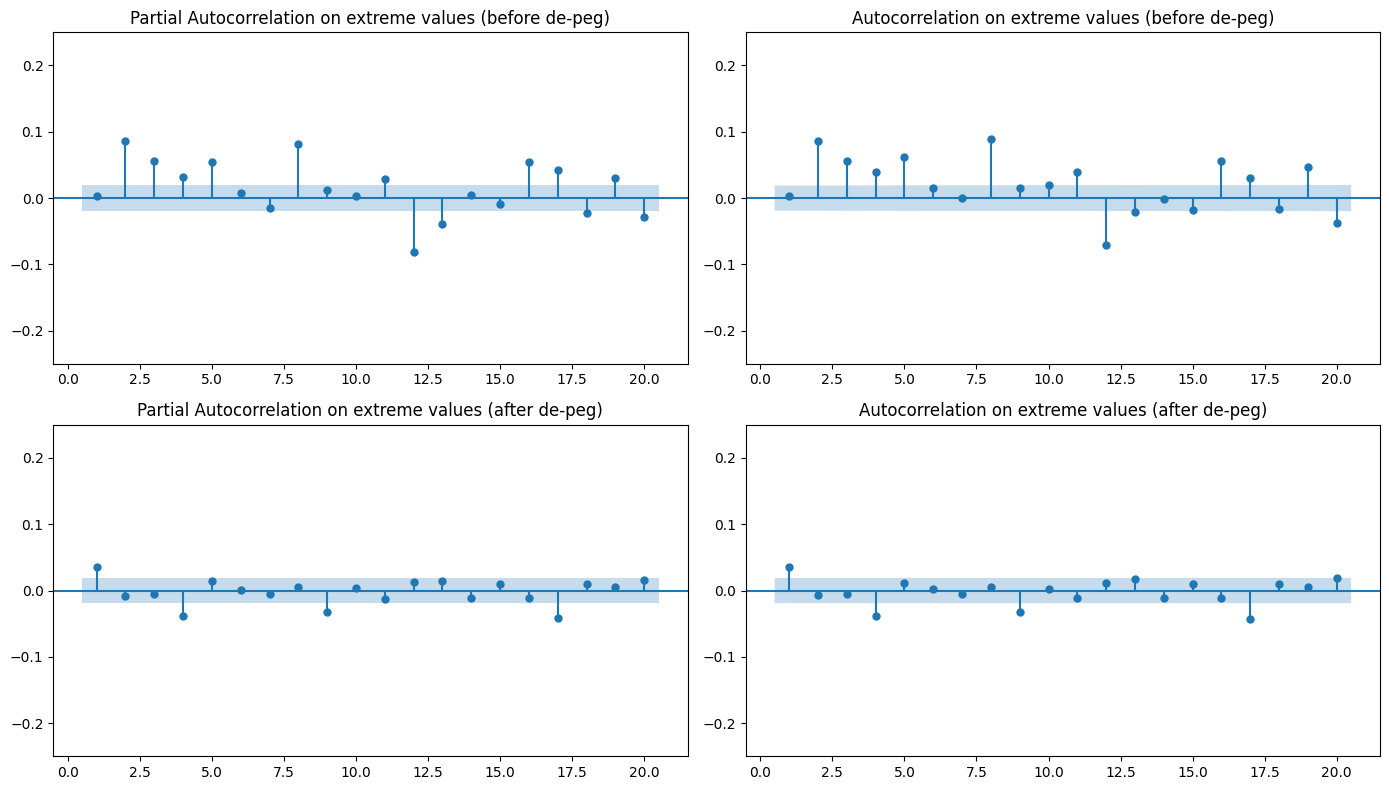

In [7]:
clipped_before = calm_before.clip(calm_before.quantile(0.005), calm_before.quantile(0.995))
clipped_after = calm_after.clip(calm_after.quantile(0.005), calm_after.quantile(0.995))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_pacf(clipped_before, ax=axes[0][0], lags=20, zero=False, title= "Partial Autocorrelation on extreme values (before de-peg)")
plot_acf(clipped_before, ax=axes[0][1], lags=20, zero=False, title= "Autocorrelation on extreme values (before de-peg)")
axes[0][0].set_ylim(-0.25, 0.25)
axes[0][1].set_ylim(-0.25, 0.25)

plot_pacf(clipped_after, ax=axes[1][0], lags=20, zero=False, title="Partial Autocorrelation on extreme values (after de-peg)")
plot_acf(clipped_after, ax=axes[1][1], lags=20, zero=False, title="Autocorrelation on extreme values (after de-peg)")
axes[1][0].set_ylim(-0.25, 0.25)
axes[1][1].set_ylim(-0.25, 0.25)


plt.tight_layout()
plt.show()

Once the 1% most extreme returns are clipped, most bars become small and positive, which does imply that some large returns (potentially the February episode) drove pre-depeg correlations.

Next, I look at squared returns, as those provide information about volatility clustering. If there is volatility clustering, I will see a lag lying above the confidence interval. Again, I generate this for all three timeframes. 

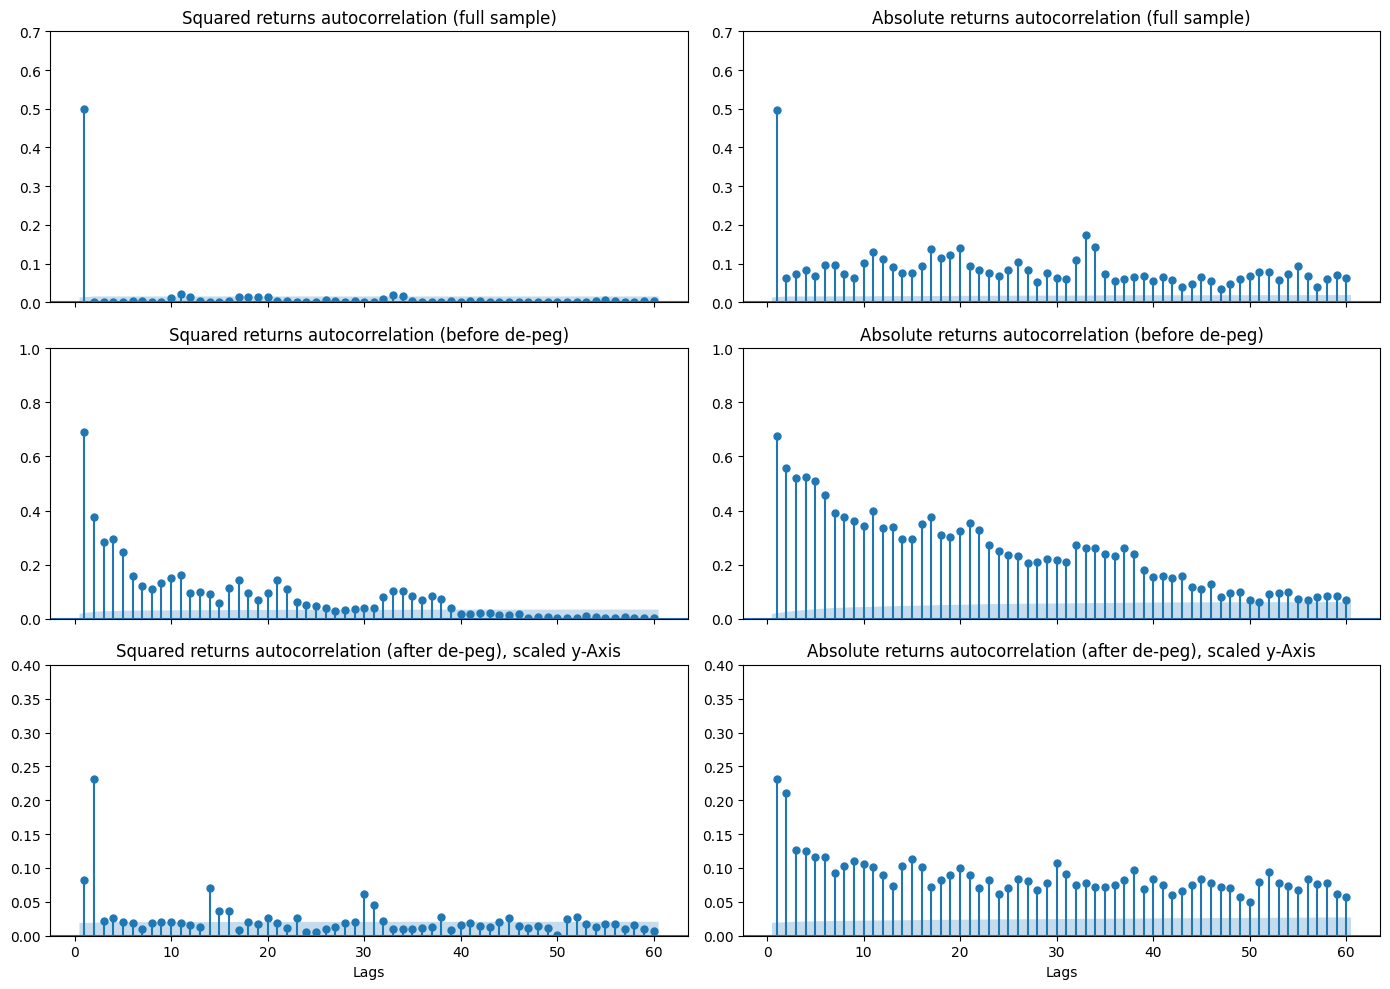

In [43]:
# Plot
fig, axes = plt.subplots(3,2, figsize=(14,10), sharex=True)

# --- Full sample ----------------------------------------------------------

square_df = df.copy()
square_df["return"] = (df["return"])**2
square_df["abs_return"] = df["return"].abs()

plot_acf(square_df["return"], ax=axes[0][0], lags=60, zero=False, title= "Squared returns autocorrelation (full sample)")
plot_acf(square_df["abs_return"], ax=axes[0][1], lags=60, zero=False, title= "Absolute returns autocorrelation (full sample)")
axes[0][0].set_ylim(0,0.7)
axes[0][1].set_ylim(0,0.7)

# --- Calm period before the depeg ------------------------------------------

calm_before = square_df.loc[calm_mask_before_the_depeg, "return"]
calm_before_abs = square_df.loc[calm_mask_before_the_depeg, "abs_return"]

plot_acf(calm_before, ax=axes[1][0], lags=60, zero=False, title= "Squared returns autocorrelation (before de-peg)")
plot_acf(calm_before_abs, ax=axes[1][1], lags=60, zero=False, title= "Absolute returns autocorrelation (before de-peg)")
axes[1][0].set_ylim(0,1)
axes[1][1].set_ylim(0,1)

# --- Calm period after the depeg ------------------------------------------

calm_after = square_df.loc[calm_mask_after_the_depeg, "return"]
calm_after_abs = square_df.loc[calm_mask_after_the_depeg, "abs_return"]

plot_acf(calm_after, ax=axes[2][0], lags=60, zero=False, title="Squared returns autocorrelation (after de-peg), scaled y-Axis")
plot_acf(calm_after_abs, ax=axes[2][1], lags=60, zero=False, title="Absolute returns autocorrelation (after de-peg), scaled y-Axis")
axes[2][0].set_xlabel("Lags")
axes[2][1].set_xlabel("Lags")
axes[2][0].set_ylim(0,0.4)
axes[2][1].set_ylim(0,0.4)

plt.tight_layout()
plt.show()

What I immediately notice is the weird 0.5 lag 1 autocorrelation across the entire sample. It basically implies that within one 5min interval a huge trade pushed the price up or down and immediately afterwards got reversed back to the same price in the following period. While it shows the arbitrage / peg mechanism working and rectifying huge price moves, the size of these movements will unnaturally push my results up.

For example, on 2023-03-12 9:00:00 the price fell by around 30 cents from 0.9456 to 0.6406 and bounced back at 2023-03-12 09:05:00 to 0.9448. The overall price movement is still quite decent, but having this 3900 basis points jump corrupts my results. 

In [17]:
sq = df["return"] ** 2
for t in sq.nlargest(10).index:
    print(df.loc[t - pd.Timedelta("10min"): t + pd.Timedelta("10min"), ["price", "return"]])
    print()

                              price       return
timestamp                                       
2023-03-12 08:50:00+00:00  0.945575     0.000000
2023-03-12 08:55:00+00:00  0.945575     0.000000
2023-03-12 09:00:00+00:00  0.640627 -3893.460799
2023-03-12 09:05:00+00:00  0.944779  3885.041221
2023-03-12 09:10:00+00:00  0.944779     0.000000

                              price       return
timestamp                                       
2023-03-12 08:55:00+00:00  0.945575     0.000000
2023-03-12 09:00:00+00:00  0.640627 -3893.460799
2023-03-12 09:05:00+00:00  0.944779  3885.041221
2023-03-12 09:10:00+00:00  0.944779     0.000000
2023-03-12 09:15:00+00:00  0.946777    21.117150

                              price       return
timestamp                                       
2023-03-11 19:15:00+00:00  0.940840   -23.716316
2023-03-11 19:20:00+00:00  0.814826 -1437.981152
2023-03-11 19:25:00+00:00  0.941300  1442.871922
2023-03-11 19:30:00+00:00  0.942960    17.614541
2023-03-11 19:35:0

Therefore, I clean the data by naming an arbitrary value (e.g. 0.5%) after which I remove the spike in hopes of removing the effect that these large rebounces have. I name 0.5% because for stablecoins this is an large selloff already, and if it is just a bounce back and forth this will heavily impact my data. Bounces over multiple periods are fine and great, and small bounces are also okay, because they show mean-reversion, which is expected.

In [33]:
spike = (
    (df["return"].abs() > 500)
    & (df["return"].shift(-1).abs() > 500)
    & (np.sign(df["return"]) != np.sign(df["return"].shift(-1)))
    & ((df["return"] + df["return"].shift(-1) < 0.1 * df["return"].abs()))
)
print(df.index[spike])
print()
print()

clean_df = df.copy()
clean_df.loc[spike, "price"] = np.nan
clean_df["price"] = clean_df["price"].ffill()
clean_df["return"] = 10000 * np.log(clean_df["price"] / clean_df["price"].shift(1))
clean_df = clean_df.dropna()
print("Clean_df is now the following:")
clean_df.describe()

DatetimeIndex(['2023-03-10 23:10:00+00:00', '2023-03-11 05:05:00+00:00',
               '2023-03-11 07:45:00+00:00', '2023-03-11 10:30:00+00:00',
               '2023-03-11 17:35:00+00:00', '2023-03-11 19:20:00+00:00',
               '2023-03-12 08:05:00+00:00', '2023-03-12 09:00:00+00:00',
               '2023-03-13 03:40:00+00:00'],
              dtype='datetime64[us, UTC]', name='timestamp', freq=None)


Clean_df is now the following:


,price,return
count,25631.000000,25631.000000
mean,0.997997,-0.000163
std,0.009103,17.656798
min,0.859451,-758.838075
25%,0.999203,-0.001898
50%,0.999689,0.000000
75%,0.999865,0.002339
max,1.000222,910.389740


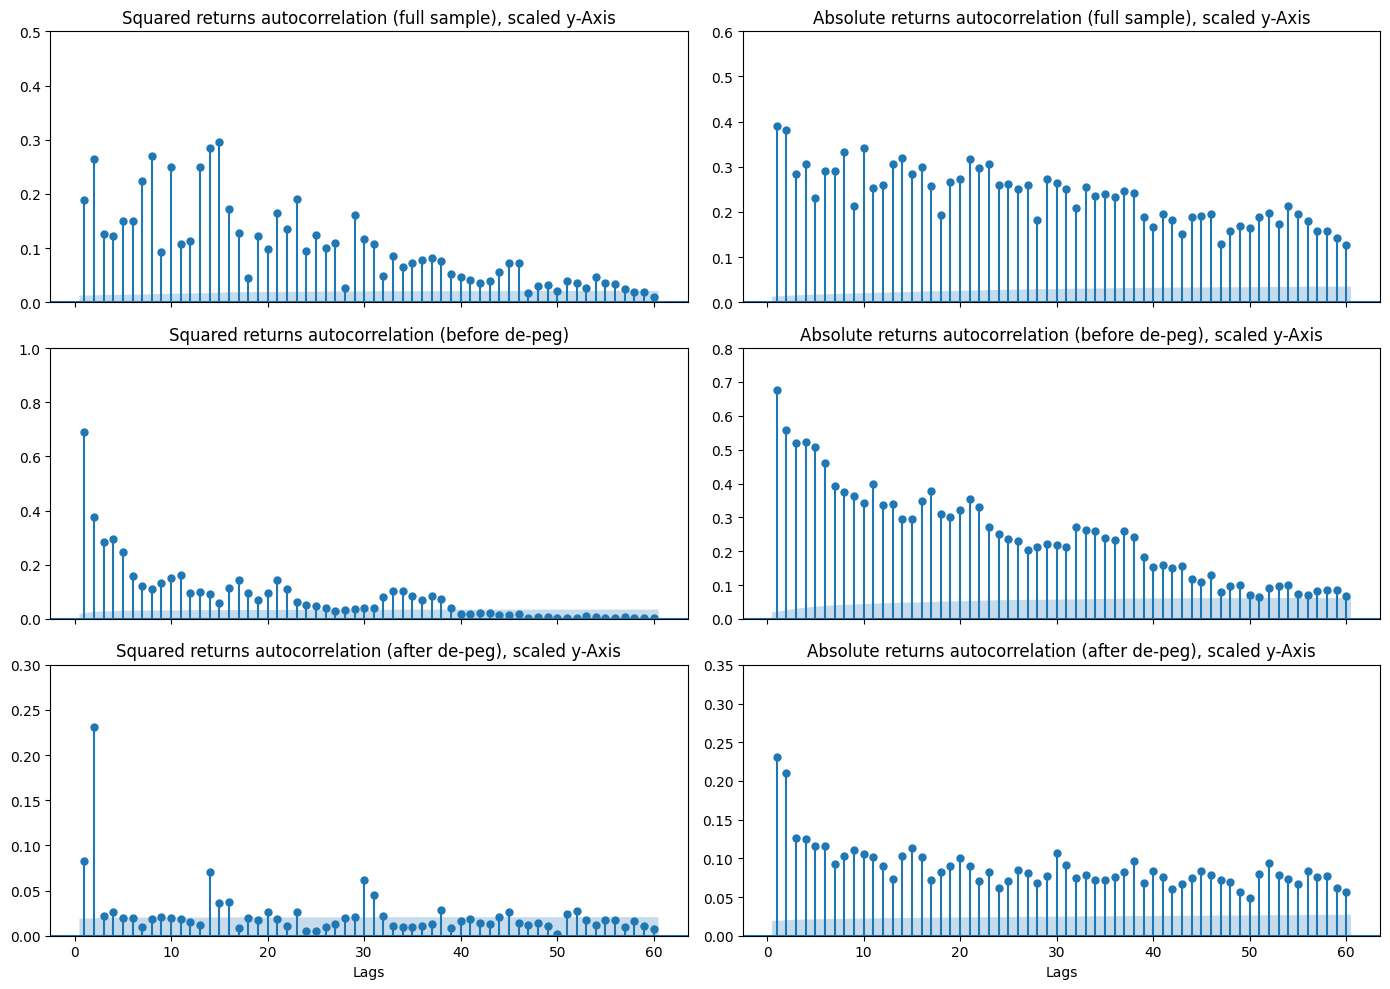

In [38]:
fig, axes = plt.subplots(3,2, figsize=(14,10), sharex=True)

clean_calm_mask_after_the_depeg = clean_df.index > "2023-03-25"
clean_calm_mask_before_the_depeg = clean_df.index < "2023-03-10"


# --- Full sample ----------------------------------------------------------

clean_square_df = clean_df.copy()
clean_square_df["return"] = (clean_df["return"])**2
clean_square_df["abs_return"] = clean_df["return"].abs()

plot_acf(clean_square_df["return"], ax=axes[0][0], lags=60, zero=False, title= "Squared returns autocorrelation (full sample), scaled y-Axis")
plot_acf(clean_square_df["abs_return"], ax=axes[0][1], lags=60, zero=False, title= "Absolute returns autocorrelation (full sample), scaled y-Axis")
axes[0][0].set_ylim(0, 0.5)
axes[0][1].set_ylim(0, 0.6)

# --- Calm period before the depeg ------------------------------------------

calm_before = clean_square_df.loc[clean_calm_mask_before_the_depeg, "return"]
calm_before_abs = clean_square_df.loc[clean_calm_mask_before_the_depeg, "abs_return"]

plot_acf(calm_before, ax=axes[1][0], lags=60, zero=False, title= "Squared returns autocorrelation (before de-peg)")
plot_acf(calm_before_abs, ax=axes[1][1], lags=60, zero=False, title= "Absolute returns autocorrelation (before de-peg), scaled y-Axis")
axes[1][0].set_ylim(0, 1)
axes[1][1].set_ylim(0, 0.8)

# --- Calm period after the depeg ------------------------------------------

calm_after = clean_square_df.loc[clean_calm_mask_after_the_depeg, "return"]
calm_after_abs = clean_square_df.loc[clean_calm_mask_after_the_depeg, "abs_return"]

plot_acf(calm_after, ax=axes[2][0], lags=60, zero=False, title="Squared returns autocorrelation (after de-peg), scaled y-Axis")
plot_acf(calm_after_abs, ax=axes[2][1], lags=60, zero=False, title= "Absolute returns autocorrelation (after de-peg), scaled y-Axis")
axes[2][0].set_xlabel("Lags")
axes[2][1].set_xlabel("Lags")
axes[2][0].set_ylim(0, 0.3)
axes[2][1].set_ylim(0, 0.35)

plt.tight_layout()
plt.show()

I will continue working with this. Throughout the sample, albeit carried by the de-peg period, there is real volatility clustering, decaying over ~60 lags (=5h). Clustering before the de-peg event is most likely largely carried by the mid-February event, while the spike at lag 2 for after the de-peg event comes from a price change of 2bsp and subsequent rebounce 10min later.

Using absolute returns instead of squared returns paints a much clearer picture. Volatility clustering is definitely there, in each of the three sub-periods. Squared returns are driven largely by high-basis-point returns, which is still clearly visible in the after-de-peg subsample. 

But decaying importance of higher lags is exactly what I want to see.

--- 

## ARIMA model fitting
Now I need to estimate a AR(I)MA model on my data to compute residuals.

In [47]:
clean_df.describe()
arma = ARIMA(clean_df["return"], order=(0,0,1)).fit()
resid = arma.resid
resid = resid - resid.mean()

print(het_arch(resid, nlags=10))              # ARCH-LM: pass residuals, NOT squared
print(acorr_ljungbox(resid ** 2, lags=10))    # McLeod–Li: pass SQUARED residuals
print(acorr_ljungbox(resid, lags=10))         # should now be much weaker

c:\Users\edka\Documents\PKU Unterlagen\Bachelor Thesis\GitHub\bachelors-thesis-hybrid-deep-learning-garch\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 5min will be used.
  self._init_dates(dates, freq)
c:\Users\edka\Documents\PKU Unterlagen\Bachelor Thesis\GitHub\bachelors-thesis-hybrid-deep-learning-garch\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 5min will be used.
  self._init_dates(dates, freq)
c:\Users\edka\Documents\PKU Unterlagen\Bachelor Thesis\GitHub\bachelors-thesis-hybrid-deep-learning-garch\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 5min will be used.
  self._init_dates(dates, freq)


(np.float64(4401.927554042681), np.float64(0.0), 531.2831884906973, 0.0)
         lb_stat      lb_pvalue
1     701.012425  1.801133e-154
2    2377.304440   0.000000e+00
3    3498.114834   0.000000e+00
4    4330.463239   0.000000e+00
5    5006.970645   0.000000e+00
6    5408.493345   0.000000e+00
7    7166.875726   0.000000e+00
8    8448.607052   0.000000e+00
9    8660.615448   0.000000e+00
10  10065.647945   0.000000e+00
        lb_stat      lb_pvalue
1     88.314371   5.583630e-21
2    188.566308   1.130697e-41
3    815.556897  1.829232e-176
4    831.177211  1.354781e-178
5    896.495493  1.526057e-191
6   1128.326866  1.549722e-240
7   1271.384624  2.573870e-270
8   2432.681516   0.000000e+00
9   2434.113143   0.000000e+00
10  2471.634150   0.000000e+00


## Ljung-Box test & ARCH-LM test
Now that I have cleaned the data by looking at it, I quickly confirm my findings by running the standard tests for autocorrelation. 

## Ljung-Box Test
I run the Ljung-Box test to check if autocorrelations on 10 lags are different from zero. I use the squared residual series for this test. Again, the leading assumption is that due to both stablecoins being pegged to the US Dollar with 

In [9]:
# Run Ljung-Box & Box-Pierce
lb = acorr_ljungbox(sq_returns, lags = 10, return_df=True, boxpierce=True)
lb.round(4)

NameError: name 'sq_returns' is not defined

We see that for all 10 lags, the p-values are essentially 0, indicating the existance of ARCH effects in the underlying data.

## ARCH-LM Test
The second test I want to look at is the ARCH-LM test, which I run on the residuals. In my previous testing notebook I mistakenly used squared residuals to 

In [ ]:
lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(de_meaned_returns, nlags=10) #Function needs to output 4 values, even though I do not show them
print(f"ARCH-LM statistic : {lm_stat:.4f}")
print(f"ARCH-LM p-value : {lm_pvalue:.18f}")

ARCH-LM statistic : 11195.3940
ARCH-LM p-value : 0.000000000000000000


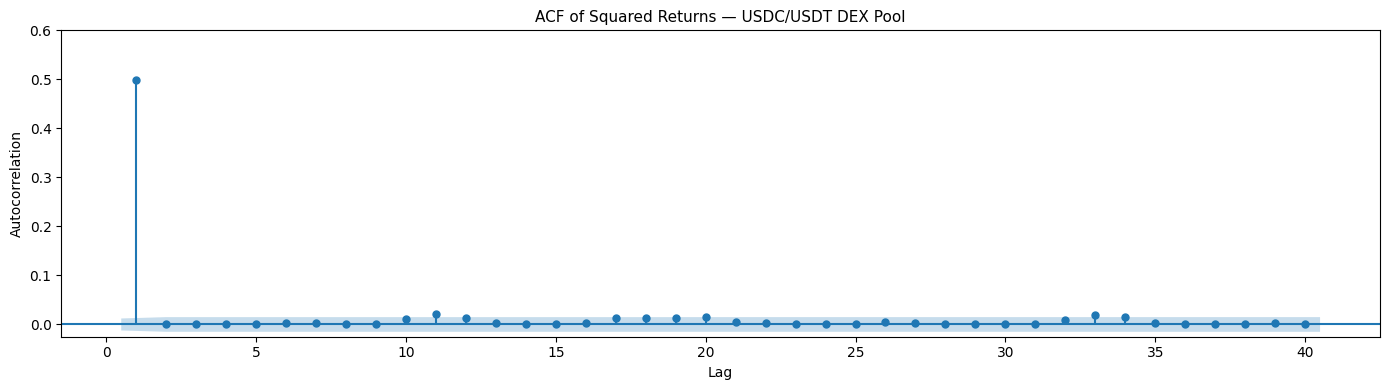

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(sq_returns, lags=40, ax=ax, zero=False) #plot the ACFs of 40 lags, remove 0 lag for visibility

ax.set_title("ACF of Squared Returns — USDC/USDT DEX Pool", fontsize=11)
ax.set_xlabel("Lag", fontsize=10)
ax.set_ylabel("Autocorrelation", fontsize=10)
ax.set_ylim(-0.025, 0.6)

plt.tight_layout()
plt.show()

In [ ]:
calm_mask_bf = df["timestamp"] < "2023-03-10"
calm_mask_af = df["timestamp"] > "2023-03-20"

calm_bf = df.loc[calm_mask_bf, "return"].dropna().values
calm_af = df.loc[calm_mask_af, "return"].dropna().values

lm_stat_bf, lm_pvalue_bf, f_stat_bf, f_pvalue_bf = het_arch(calm_bf - calm_bf.mean(), nlags=10)
print(f"ARCH-LM statistic : {lm_stat_bf:.4f}")
print(f"ARCH-LM p-value : {lm_pvalue_bf:.18f}")

lm_stat_af, lm_pvalue_af, f_stat_af, f_pvalue_af = het_arch(calm_af - calm_af.mean(), nlags=10)
print(f"ARCH-LM statistic : {lm_stat_af:.4f}")
print(f"ARCH-LM p-value : {lm_pvalue_af:.18f}")

ARCH-LM statistic : 5615.3109
ARCH-LM p-value : 0.000000000000000000
ARCH-LM statistic : 1163.6790
ARCH-LM p-value : 0.000000000000000000


In [ ]:
sq_calm_bf = calm_af ** 2
lb.bf = acorr_ljungbox(sq_calm_bf, lags = 10, return_df=True)
lb.bf.round(4)



,lb_stat,lb_pvalue
1,450.5220,0.0
2,708.4493,0.0
3,1137.8125,0.0
4,1271.7615,0.0
5,1398.1370,0.0
6,1521.3969,0.0
7,1699.2637,0.0
8,1918.2698,0.0
9,2273.1501,0.0
10,2344.7842,0.0


In [ ]:
calm_series = df.loc[calm_mask, "return"].dropna()
print((calm_series == 0).mean())
print((calm_series.abs() < 1e-9).mean())

0.04336734693877551
0.04350907029478458
